In [38]:
# Reproducibility Setup


import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Reproducibility ready")

Reproducibility ready


In [39]:
# Data Visualization Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

sns.set(style="whitegrid")

print("Libraries loaded")

Libraries loaded


In [40]:
# Load ABSA results

file_path = "../results/absa_results.csv"

absa_df = pd.read_csv(file_path)

print("ABSA results loaded")

absa_df.head()

ABSA results loaded


,text,aspect,sentiment
0,name ive been trying to call the customer serv...,customer_service,negative
1,renew annual tpo and update certificate email ...,insurance_services,neutral
2,assist with having the attached form executed ...,insurance_services,neutral
3,i got a activation code after it got locked bt...,mobile_banking_app,negative
4,i got a activation code after it got locked bt...,account_issues,negative


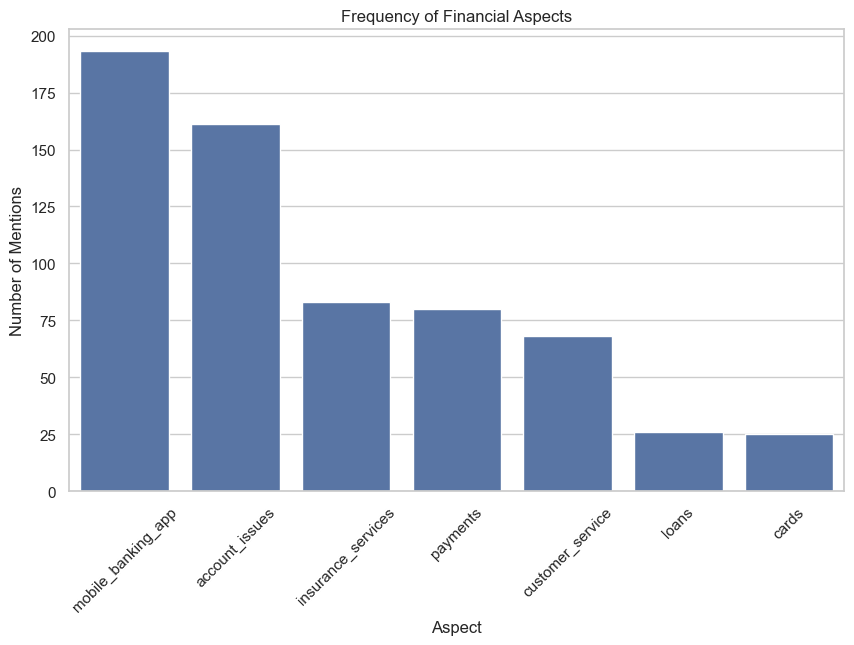

In [41]:
# Visualize aspect distribution

aspect_counts = absa_df["aspect"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=aspect_counts.index,
    y=aspect_counts.values
)

plt.title("Frequency of Financial Aspects")
plt.xlabel("Aspect")
plt.ylabel("Number of Mentions")

plt.xticks(rotation=45)

plt.show()

In [42]:
# Sentiment distribution per aspect

aspect_sentiment = pd.crosstab(
    absa_df["aspect"],
    absa_df["sentiment"]
)

aspect_sentiment

sentiment,negative,neutral,positive
aspect,,,
account_issues,101,60,0
cards,10,15,0
customer_service,41,18,9
insurance_services,10,73,0
loans,22,4,0
mobile_banking_app,139,35,19
payments,58,21,1


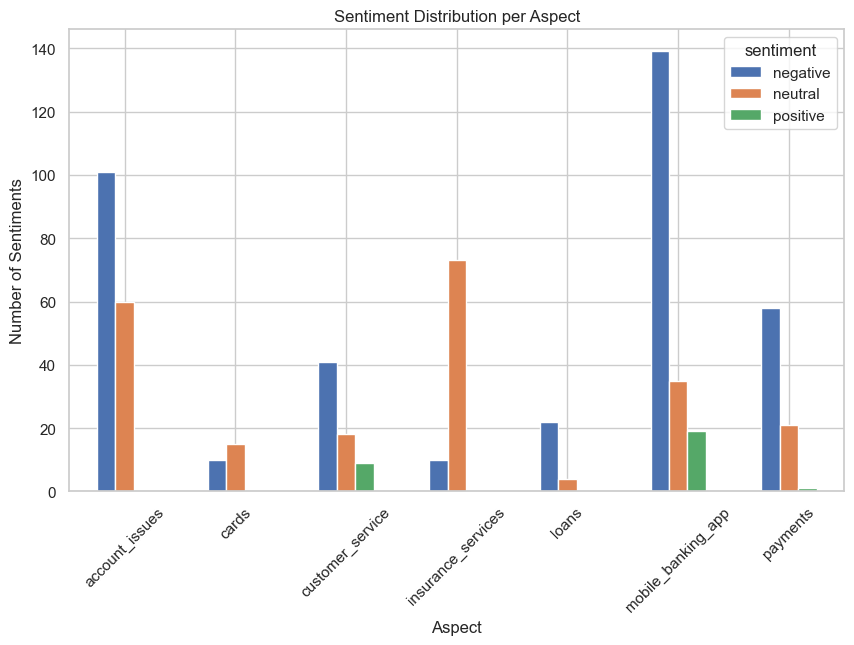

<Figure size 640x480 with 0 Axes>

In [43]:
# Visualize sentiment distribution per aspect

aspect_sentiment.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Sentiment Distribution per Aspect")

plt.xlabel("Aspect")
plt.ylabel("Number of Sentiments")

plt.xticks(rotation=45)

plt.show()

# Save the file to the results folder
plt.savefig("../results/sentiment_distribution.png", bbox_inches='tight', dpi=300)
plt.show()
#print("Distribution plot saved to ../results/sentiment_distribution.png")

Sentiment: negative


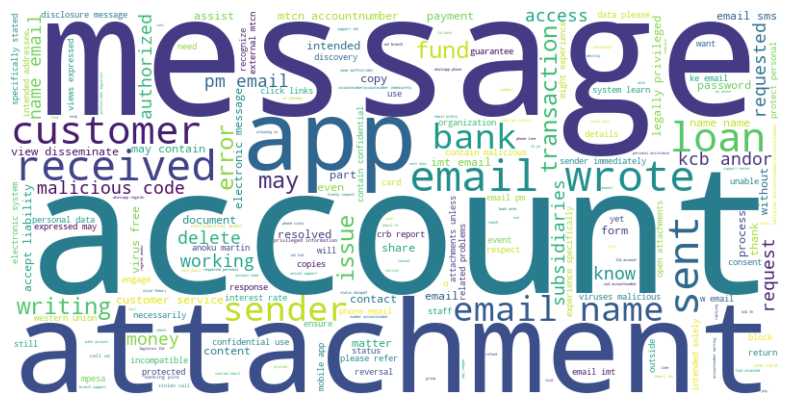

Sentiment: neutral


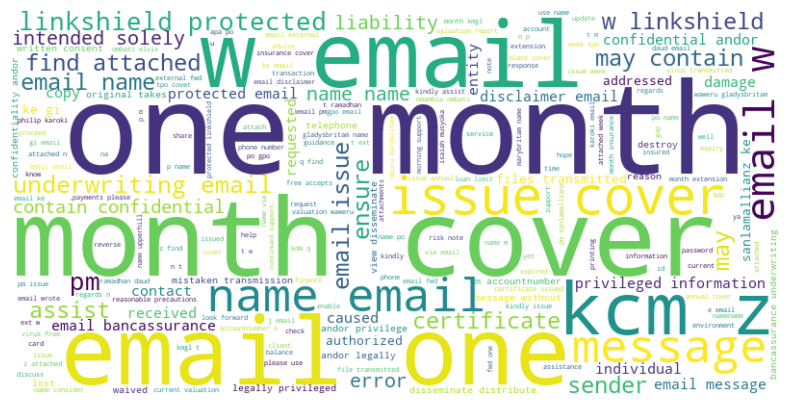

Sentiment: positive


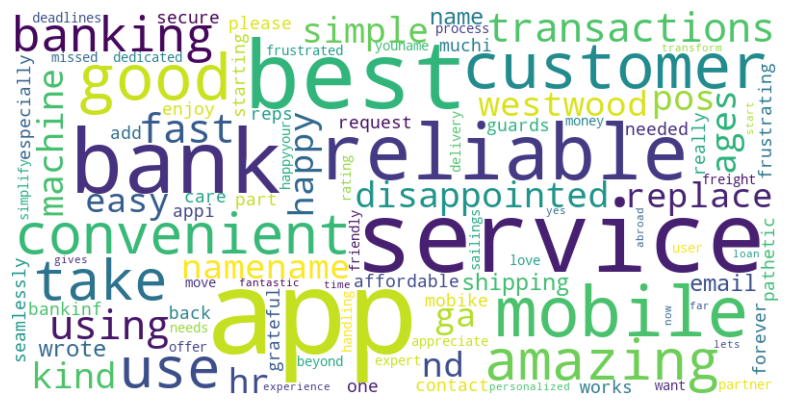

In [44]:
# Generate word clouds for each sentiment category
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1️⃣ Define the function
def generate_wordcloud(text):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

# 2️⃣ Loop over sentiment categories and generate word clouds
aspects = absa_df["sentiment"].unique()

for sentiment in aspects:
    text = " ".join(
        absa_df[absa_df["sentiment"] == sentiment]["text"].dropna().astype(str)
    )
    
    print("Sentiment:", sentiment)
    generate_wordcloud(text)

    